# ETF 申购资金赚钱效应

将每日正份额变化视为净申购，以当日单位净值估算申购金额。当前暂以累计净值比较申购日与评价日来判断赚钱；该收益口径**需验证**，累计净值并非任意期间的复权总回报。

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

使用中文字体：PingFang SC


In [2]:
shares_path = Path('data/etf_shares.parquet')
nav_path = Path('data/etf_nav.parquet')
requested_as_of_date = None  # Example: '2026-06-30'

if not shares_path.exists():
    raise FileNotFoundError('未找到 data/etf_shares.parquet，请先运行 download_etf_shares.py。')
if not nav_path.exists():
    raise FileNotFoundError('未找到 data/etf_nav.parquet，请先运行 download_etf_nav.py。')

In [3]:
SHARE_COLUMNS = {'date', 'fund_code', 'fund_name', 'total_shares'}
NAV_COLUMNS = {'trade_date', 'fund_code', 'unit_nav', 'cumulative_nav', 'daily_return_pct'}
FUND_DISPLAY_NAMES = {
    '510100': '上证50', '510310': '沪深300', '510580': '中证500',
    '159633': '中证1000', '159532': '中证2000', '563020': '红利低波', '588080': '科创50',
}

shares = pd.read_parquet(shares_path)
missing_columns = SHARE_COLUMNS - set(shares.columns)
if missing_columns:
    raise ValueError(f'份额数据缺少字段：{", ".join(sorted(missing_columns))}')
shares = shares.loc[:, sorted(SHARE_COLUMNS)].copy()
shares['fund_code'] = shares['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
shares['date'] = pd.to_datetime(shares['date'], errors='raise').dt.date
shares['total_shares'] = pd.to_numeric(shares['total_shares'], errors='raise')
if shares.duplicated(['date', 'fund_code']).any() or (shares['total_shares'] <= 0).any():
    raise ValueError('份额数据包含重复记录或非正份额。')

navs = pd.read_parquet(nav_path)
missing_columns = NAV_COLUMNS - set(navs.columns)
if missing_columns:
    raise ValueError(f'净值数据缺少字段：{", ".join(sorted(missing_columns))}')
navs = navs.loc[:, list(NAV_COLUMNS)].rename(columns={'trade_date': 'date'}).copy()
navs['fund_code'] = navs['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
navs['date'] = pd.to_datetime(navs['date'], errors='raise').dt.date
navs[['unit_nav', 'cumulative_nav', 'daily_return_pct']] = navs[['unit_nav', 'cumulative_nav', 'daily_return_pct']].apply(pd.to_numeric, errors='raise')
if navs.duplicated(['date', 'fund_code']).any() or (navs[['unit_nav', 'cumulative_nav']] <= 0).any().any():
    raise ValueError('净值数据包含重复记录或非正净值。')

fund_codes = set(shares['fund_code'])
eligible_navs = navs.loc[navs['fund_code'].isin(fund_codes)]
missing_funds = fund_codes - set(eligible_navs['fund_code'])
if missing_funds:
    raise ValueError(f'净值数据缺少基金：{", ".join(sorted(missing_funds))}')
unknown_display_names = fund_codes - set(FUND_DISPLAY_NAMES)
if unknown_display_names:
    raise ValueError(f'基金简称映射缺少代码：{", ".join(sorted(unknown_display_names))}')
if requested_as_of_date is not None:
    eligible_navs = eligible_navs.loc[eligible_navs['date'] <= pd.Timestamp(requested_as_of_date).date()]
common_dates = eligible_navs.groupby('date')['fund_code'].nunique()
common_dates = common_dates.index[common_dates == len(fund_codes)]
if common_dates.empty:
    raise ValueError('没有覆盖全部 ETF 的共同评价日。')
as_of_date = max(common_dates)

shares = shares.loc[shares['date'] <= as_of_date].sort_values(['fund_code', 'date']).copy()
shares['net_subscription_shares'] = shares.groupby('fund_code')['total_shares'].diff()
batches = shares.loc[shares['net_subscription_shares'] > 0].rename(columns={'date': 'subscription_date'}).copy()
entry_navs = navs.rename(columns={'date': 'subscription_date', 'cumulative_nav': 'entry_cumulative_nav'}).loc[:, ['subscription_date', 'fund_code', 'unit_nav', 'entry_cumulative_nav']]
batches = batches.merge(entry_navs, on=['subscription_date', 'fund_code'], how='left', validate='one_to_one')
as_of_navs = navs.loc[navs['date'] == as_of_date, ['fund_code', 'cumulative_nav']].rename(columns={'cumulative_nav': 'as_of_cumulative_nav'})
batches = batches.merge(as_of_navs, on='fund_code', how='left', validate='many_to_one')
if batches[['unit_nav', 'entry_cumulative_nav', 'as_of_cumulative_nav']].isna().any().any():
    raise ValueError('部分申购批次缺少净值数据。')
batches['estimated_subscription_amount'] = batches['net_subscription_shares'] * batches['unit_nav']
batches['holding_return'] = batches['as_of_cumulative_nav'] / batches['entry_cumulative_nav'] - 1
batches['profitable'] = batches['holding_return'] > 0

summary = batches.groupby('fund_code', as_index=False).agg(
    subscription_amount=('estimated_subscription_amount', 'sum'),
    profitable_amount=('estimated_subscription_amount', lambda amount: amount[batches.loc[amount.index, 'profitable']].sum()),
    subscription_batches=('profitable', 'size'),
)
summary['display_name'] = summary['fund_code'].map(FUND_DISPLAY_NAMES)
summary['profitable_capital_ratio'] = summary['profitable_amount'] / summary['subscription_amount']
total_subscription_amount = batches['estimated_subscription_amount'].sum()
total_profitable_amount = batches.loc[batches['profitable'], 'estimated_subscription_amount'].sum()
overall = pd.DataFrame([{
    'fund_code': 'ALL', 'display_name': '总体', 'subscription_amount': total_subscription_amount,
    'profitable_amount': total_profitable_amount, 'subscription_batches': len(batches),
    'profitable_capital_ratio': total_profitable_amount / total_subscription_amount if total_subscription_amount else float('nan'),
}])
summary = pd.concat([summary, overall], ignore_index=True)

实际评价日：2026-07-16


,基金简称,正净申购金额,赚钱资金金额,申购批次数,赚钱资金比例
0,中证2000,"124,058,000","15,573,200",27,12.6%
1,中证1000,"7,299,308,700","470,972,700",50,6.5%
2,上证50,"4,726,826,370","2,343,949,110",50,49.6%
3,沪深300,"8,628,730,020","6,453,986,220",34,74.8%
4,中证500,"2,214,989,760","334,139,040",65,15.1%
5,红利低波,"8,419,239,200","1,831,976,200",103,21.8%
6,科创50,"11,305,173,600","7,079,346,600",46,62.6%
7,总体,"42,718,325,650","18,529,943,070",375,43.4%


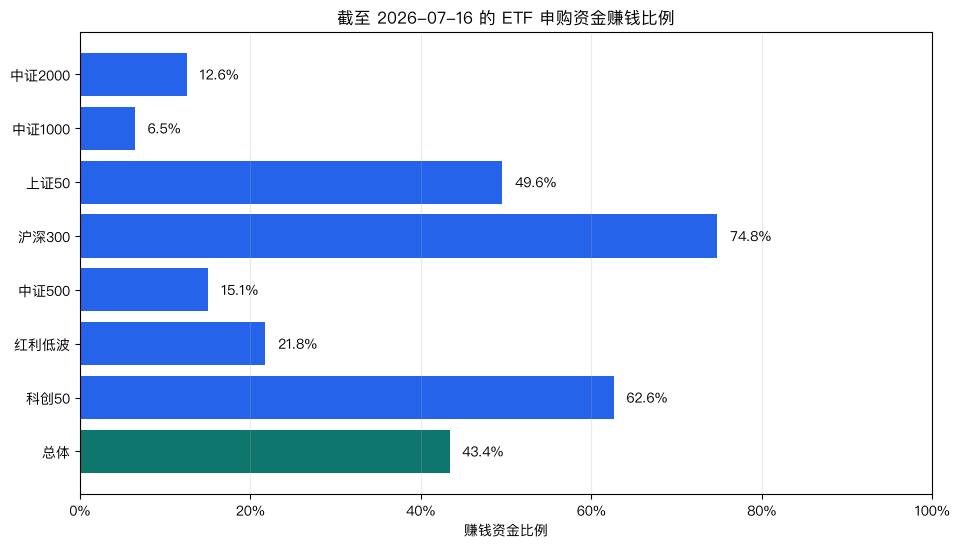

In [4]:
print(f'实际评价日：{as_of_date}')
display_summary = summary.loc[:, ['display_name', 'subscription_amount', 'profitable_amount', 'subscription_batches', 'profitable_capital_ratio']].rename(columns={
    'display_name': '基金简称',
    'subscription_amount': '正净申购金额', 'profitable_amount': '赚钱资金金额',
    'subscription_batches': '申购批次数', 'profitable_capital_ratio': '赚钱资金比例',
})
display(display_summary.style.format({
    '正净申购金额': '{:,.0f}', '赚钱资金金额': '{:,.0f}', '赚钱资金比例': '{:.1%}',
}))

labels = summary['display_name']
ratios = summary['profitable_capital_ratio'].fillna(0)
colors = ['#0F766E' if code == 'ALL' else '#2563EB' for code in summary['fund_code']]
figure, axis = plt.subplots(figsize=(11, 6))
bars = axis.barh(labels, ratios, color=colors)
axis.set_xlim(0, 1)
axis.xaxis.set_major_formatter(PercentFormatter(1))
axis.set_xlabel('赚钱资金比例')
axis.set_title(f'截至 {as_of_date} 的 ETF 申购资金赚钱比例')
axis.grid(axis='x', alpha=0.25)
axis.invert_yaxis()
for bar, ratio in zip(bars, ratios):
    axis.text(min(ratio + 0.015, 0.94), bar.get_y() + bar.get_height() / 2, f'{ratio:.1%}', va='center')
plt.show()

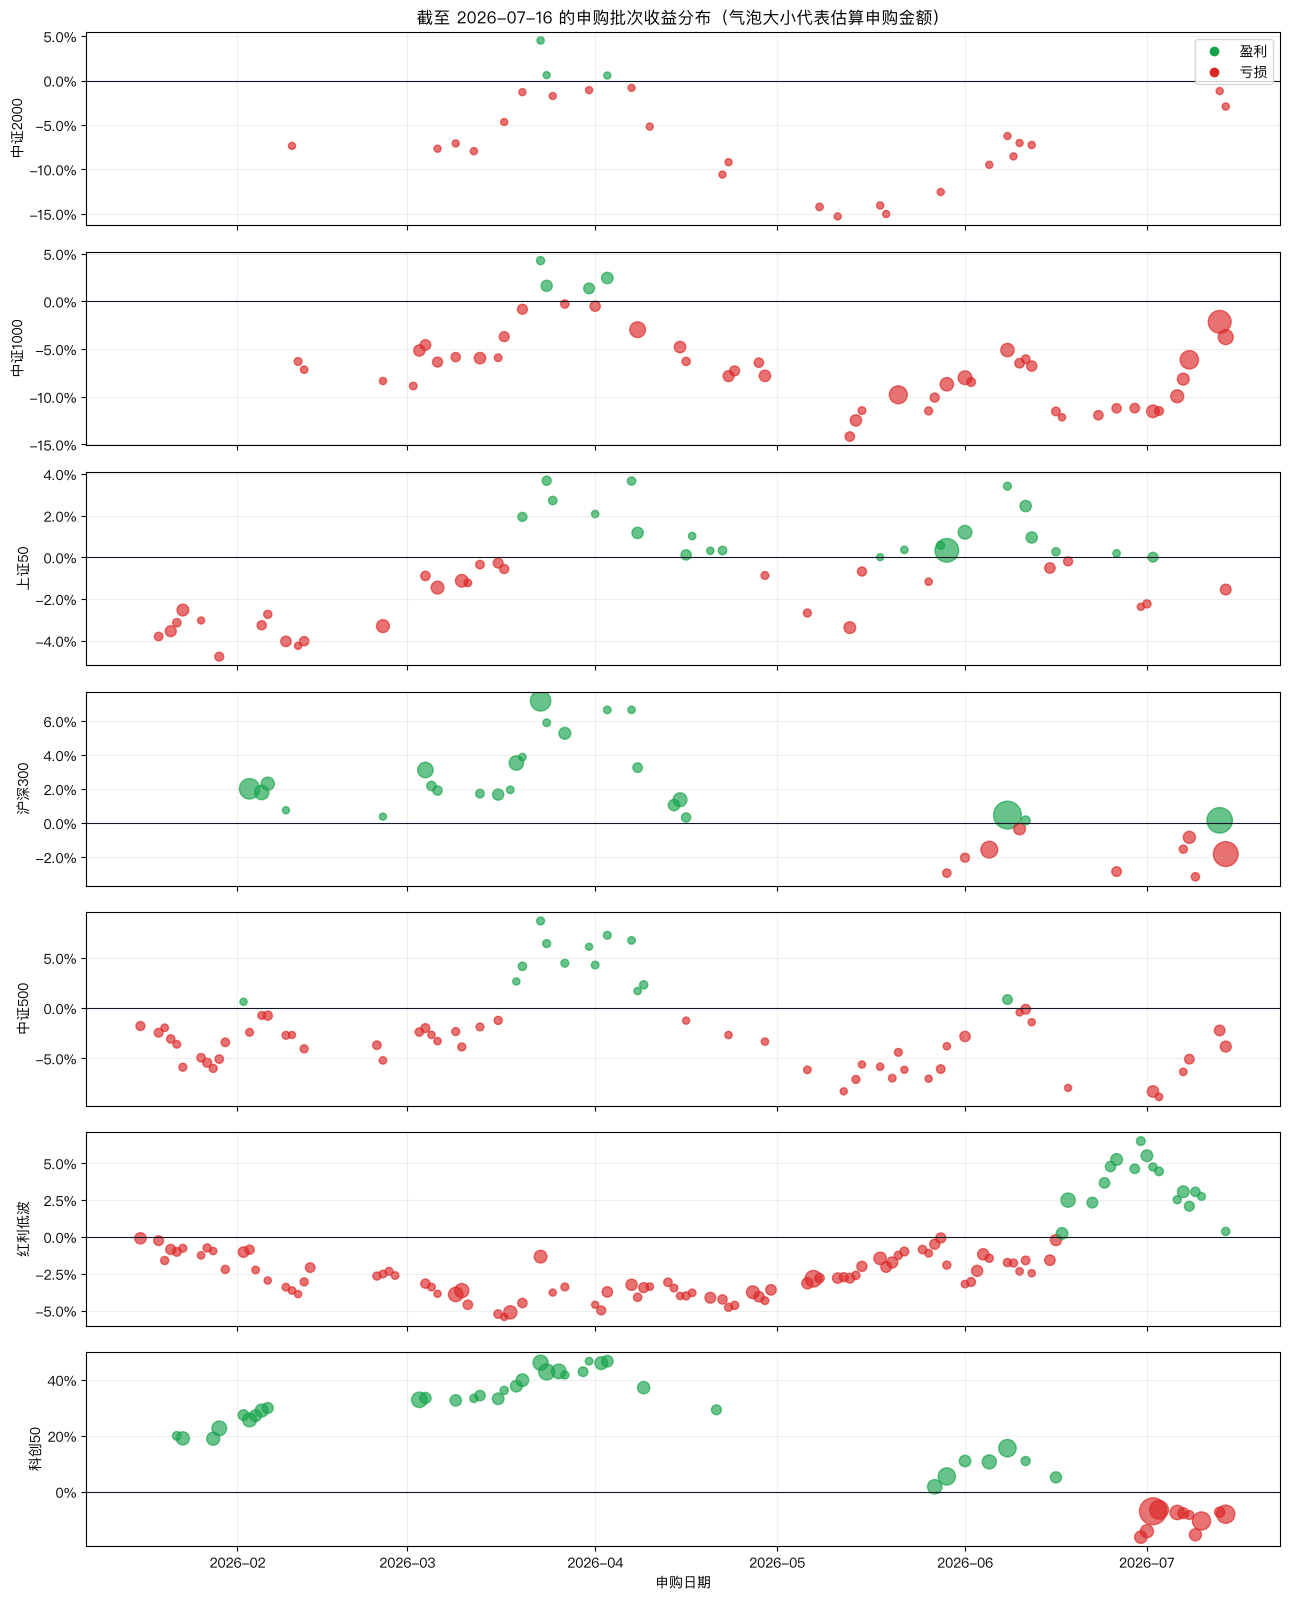

In [5]:
fund_code_list = summary.loc[summary['fund_code'] != 'ALL', 'fund_code'].tolist()
figure, axes = plt.subplots(len(fund_code_list), 1, figsize=(13, max(4, 2.3 * len(fund_code_list))), sharex=True)
maximum_amount = batches['estimated_subscription_amount'].max() if not batches.empty else 1

for axis, fund_code in zip(axes, fund_code_list):
    data = batches.loc[batches['fund_code'] == fund_code]
    if data.empty:
        axis.text(0.5, 0.5, '无正净申购批次', ha='center', va='center', transform=axis.transAxes)
    else:
        bubble_sizes = 25 + 375 * data['estimated_subscription_amount'] / maximum_amount
        colors = data['profitable'].map({True: '#16A34A', False: '#DC2626'})
        axis.scatter(data['subscription_date'], data['holding_return'], s=bubble_sizes, c=colors, alpha=0.65)
    axis.axhline(0, color='#111827', linewidth=0.8)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.set_ylabel(FUND_DISPLAY_NAMES[fund_code])
    axis.grid(alpha=0.2)

axes[0].set_title(f'截至 {as_of_date} 的申购批次收益分布（气泡大小代表估算申购金额）')
axes[0].legend(handles=[
    Line2D([], [], marker='o', linestyle='', color='#16A34A', label='盈利'),
    Line2D([], [], marker='o', linestyle='', color='#DC2626', label='亏损'),
], loc='upper right')
axes[-1].set_xlabel('申购日期')
plt.tight_layout()
plt.show()